In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load data from CSV file
data = pd.read_csv("Liver Patient Dataset (LPD)_train.csv", encoding="latin-1")

In [3]:
data.head()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  str    
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4   Alkaline Phosphotase                  29895 non-null  float64
 5   Alamine Aminotransferase              30153 non-null  float64
 6   Aspartate Aminotransferase            30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8   Albumin                               30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), int64(1), s

In [4]:
# rename columns to standard names
data.rename(
    columns={
        'Age of the patient': 'Age',
        'Gender of the patient': 'Gender',
        'Total Bilirubin': 'Total_Bilirubin',
        'Direct Bilirubin': 'Direct_Bilirubin',
        'Alkaline Phosphotase': 'Alkaline_Phosphotase',
        'Alamine Aminotransferase': 'Alamine_Aminotransferase',
        'Aspartate Aminotransferase': 'Aspartate_Aminotransferase',
        'Total Protiens': 'Total_Protiens',
        'Albumin': 'Albumin',
        'A/G Ratio Albumin and Globulin Ratio': 'Albumin_and_Globulin_Ratio',
        'Result': 'Dataset',
    },
    inplace=True,
 )

In [5]:
data.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,30689.000000,30043.000000,30130.000000,29895.000000,30153.000000,30229.000000,30228.000000,30197.000000,30132.000000,30691.000000
mean,44.107205,3.370319,1.528042,289.075364,81.488641,111.469979,6.480237,3.130142,0.943467,1.285882
std,15.981043,6.255522,2.869592,238.537589,182.158850,280.851078,1.081980,0.792281,0.323164,0.451841
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,32.000000,0.800000,0.200000,175.000000,23.000000,26.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,209.000000,35.000000,42.000000,6.600000,3.100000,0.900000,1.000000
75%,55.000000,2.700000,1.300000,298.000000,62.000000,88.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [6]:
#check the blank data in attributes in a/g ratio
data.isnull().sum()


Age                             2
Gender                        902
Total_Bilirubin               648
Direct_Bilirubin              561
Alkaline_Phosphotase          796
Alamine_Aminotransferase      538
Aspartate_Aminotransferase    462
Total_Protiens                463
Albumin                       494
Albumin_and_Globulin_Ratio    559
Dataset                         0
dtype: int64

In [7]:
import numpy as np
mean_ag = data['Albumin_and_Globulin_Ratio'].mean()
data['Albumin_and_Globulin_Ratio'] = data['Albumin_and_Globulin_Ratio'].fillna(mean_ag)

In [8]:
# label encode Gender using sklearn
from sklearn.preprocessing import LabelEncoder
data['Gender'] = data['Gender'].fillna('Unknown').astype(str)
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

In [9]:
mean_age= np.mean(data['Age'])
data['Age'] = data['Age'].fillna(mean_age)


In [10]:
globulin = data['Albumin_and_Globulin_Ratio'] * data['Albumin']
protein = data['Albumin'] + globulin
data.loc[data['Total_Protiens'].isna(), 'Total_Protiens'] = protein

In [11]:
data.drop_duplicates(inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 19365 entries, 0 to 30689
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         19365 non-null  float64
 1   Gender                      19365 non-null  int64  
 2   Total_Bilirubin             18808 non-null  float64
 3   Direct_Bilirubin            18875 non-null  float64
 4   Alkaline_Phosphotase        18671 non-null  float64
 5   Alamine_Aminotransferase    18906 non-null  float64
 6   Aspartate_Aminotransferase  18972 non-null  float64
 7   Total_Protiens              19269 non-null  float64
 8   Albumin                     18952 non-null  float64
 9   Albumin_and_Globulin_Ratio  19365 non-null  float64
 10  Dataset                     19365 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.8 MB


In [12]:
data.isna().sum()

Age                             0
Gender                          0
Total_Bilirubin               557
Direct_Bilirubin              490
Alkaline_Phosphotase          694
Alamine_Aminotransferase      459
Aspartate_Aminotransferase    393
Total_Protiens                 96
Albumin                       413
Albumin_and_Globulin_Ratio      0
Dataset                         0
dtype: int64

In [13]:
data.dropna(inplace=True)
data.info()


<class 'pandas.DataFrame'>
Index: 17214 entries, 0 to 30689
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         17214 non-null  float64
 1   Gender                      17214 non-null  int64  
 2   Total_Bilirubin             17214 non-null  float64
 3   Direct_Bilirubin            17214 non-null  float64
 4   Alkaline_Phosphotase        17214 non-null  float64
 5   Alamine_Aminotransferase    17214 non-null  float64
 6   Aspartate_Aminotransferase  17214 non-null  float64
 7   Total_Protiens              17214 non-null  float64
 8   Albumin                     17214 non-null  float64
 9   Albumin_and_Globulin_Ratio  17214 non-null  float64
 10  Dataset                     17214 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.6 MB


In [14]:
data.to_csv("liver_data_cleaned.csv", index=False)

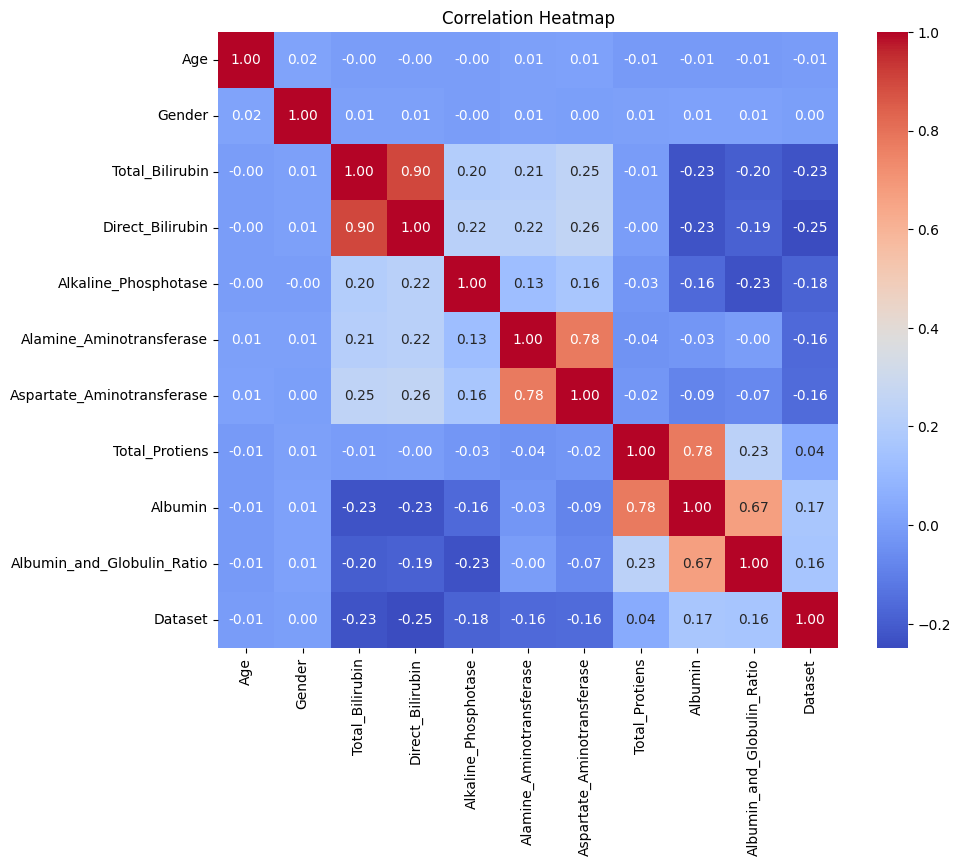

In [15]:
# make the correlation heatmap
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
# Check for outliers using IQR method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outlier=((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()
print("Number of outliers in each column:\n", outlier)


Number of outliers in each column:
 Age                             43
Gender                           0
Total_Bilirubin               2515
Direct_Bilirubin              2437
Alkaline_Phosphotase          1955
Alamine_Aminotransferase      2138
Aspartate_Aminotransferase    2000
Total_Protiens                 278
Albumin                          0
Albumin_and_Globulin_Ratio     307
Dataset                          0
dtype: int64


In [17]:

from sklearn.preprocessing import StandardScaler

stand=StandardScaler()
data_scaled=stand.fit_transform(data)


In [18]:
from sklearn.model_selection import train_test_split
x=data.drop(['Dataset','Gender'],axis=1)
y=data['Dataset']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [20]:
from sklearn.linear_model import LogisticRegression
logmodel=LogisticRegression(max_iter=1000)
logmodel.fit(x_train,y_train)   
y_pred_logist=logmodel.predict(x_test)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))  
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[2468    0]
 [ 975    0]]
Classification Report:
               precision    recall  f1-score   support

           1       0.72      1.00      0.84      2468
           2       0.00      0.00      0.00       975

    accuracy                           0.72      3443
   macro avg       0.36      0.50      0.42      3443
weighted avg       0.51      0.72      0.60      3443

Accuracy Score: 0.7168167295962823


In [22]:
print("Confusion Matrix for Logistic Regression:\n", confusion_matrix(y_test, y_pred_logist))
print(classification_report(y_test, y_pred_logist, zero_division=0))
print("Accuracy Score for Logistic Regression:", accuracy_score(y_test, y_pred_logist))

Confusion Matrix for Logistic Regression:
 [[2312  156]
 [ 777  198]]
              precision    recall  f1-score   support

           1       0.75      0.94      0.83      2468
           2       0.56      0.20      0.30       975

    accuracy                           0.73      3443
   macro avg       0.65      0.57      0.57      3443
weighted avg       0.69      0.73      0.68      3443

Accuracy Score for Logistic Regression: 0.7290153935521347


In [23]:

# K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

print("K-Nearest Neighbors Classification Report:\n", classification_report(y_test, y_pred_knn, zero_division=0))
print("K-Nearest Neighbors Accuracy:", accuracy_score(y_test, y_pred_knn))


K-Nearest Neighbors Classification Report:
               precision    recall  f1-score   support

           1       0.97      0.96      0.97      2468
           2       0.91      0.92      0.91       975

    accuracy                           0.95      3443
   macro avg       0.94      0.94      0.94      3443
weighted avg       0.95      0.95      0.95      3443

K-Nearest Neighbors Accuracy: 0.9506244554167876


In [24]:

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt, zero_division=0))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Classification Report:
               precision    recall  f1-score   support

           1       0.97      0.81      0.88      2468
           2       0.66      0.93      0.77       975

    accuracy                           0.84      3443
   macro avg       0.81      0.87      0.83      3443
weighted avg       0.88      0.84      0.85      3443

Decision Tree Accuracy: 0.8449027011327331


In [25]:

# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(x_train, y_train)
y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Classification Report:\n", classification_report(y_test, y_pred_gb, zero_division=0))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))


Gradient Boosting Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.98      0.93      2468
           2       0.93      0.65      0.76       975

    accuracy                           0.89      3443
   macro avg       0.90      0.81      0.84      3443
weighted avg       0.89      0.89      0.88      3443

Gradient Boosting Accuracy: 0.8861458030787104


In [26]:

# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00      2468
           2       1.00      1.00      1.00       975

    accuracy                           1.00      3443
   macro avg       1.00      1.00      1.00      3443
weighted avg       1.00      1.00      1.00      3443

Random Forest Accuracy: 1.0


In [27]:
import pickle
pickle.dump(knn_model,open('model_knn.pkl','wb'))

In [28]:
import pickle
pickle.dump(rf_model,open('model_rain.pkl','wb'))

In [29]:

# Model Comparison - Summary
import pandas as pd
models_summary = pd.DataFrame({
    'Model': ['SVM', 'Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Decision Tree', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_logist),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ]
})

print("Model Accuracy Comparison:\n", models_summary)
print("\nBest Model:", models_summary.loc[models_summary['Accuracy'].idxmax(), 'Model'])


Model Accuracy Comparison:
                  Model  Accuracy
0                  SVM  0.716817
1  Logistic Regression  0.729015
2        Random Forest  1.000000
3    Gradient Boosting  0.886146
4        Decision Tree  0.844903
5                  KNN  0.950624

Best Model: Random Forest
